In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import sys
sys.path.append('..')

from src.network import Network
from src.layers import Dense
from src.activations import ReLU, Softmax
from src.losses import CrossEntropyLoss

In [2]:
print("Pobieranie MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

X = X / 255.0

y_onehot = np.zeros((len(y), 10))
y_onehot[np.arange(len(y)), y] = 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Pobieranie MNIST...
Train: (56000, 784), Test: (14000, 784)


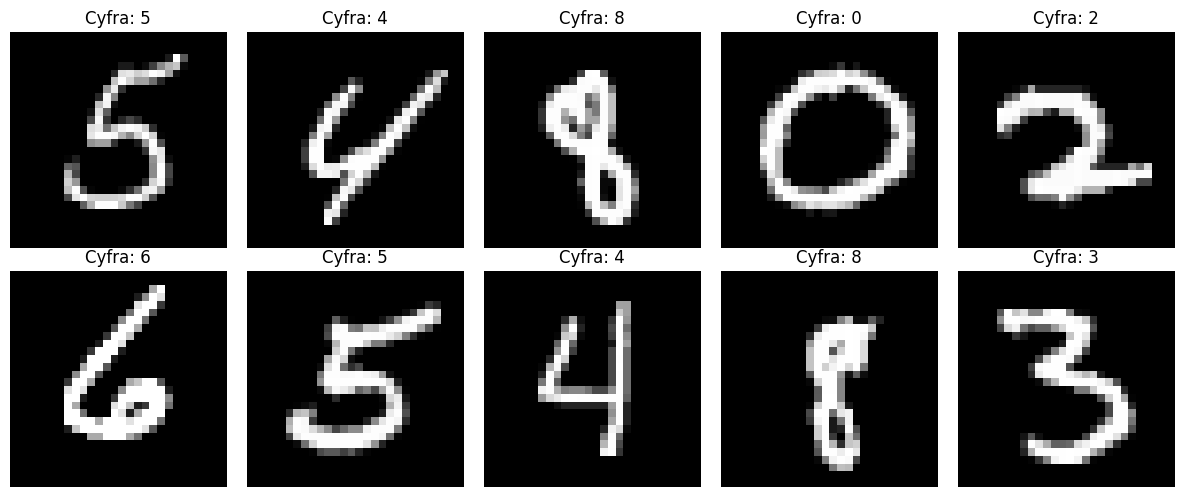

In [3]:
# Podgląd kilku cyfr
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Cyfra: {np.argmax(y_train[i])}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [4]:
model = Network()
model.add(Dense(784, 128))
model.add(ReLU())
model.add(Dense(128, 64))
model.add(ReLU())
model.add(Dense(64, 10))
model.add(Softmax())

model.train(X_train, y_train, epochs=100, lr=0.01, batch_size=32)

Epoch   0 | loss: 0.3239 | acc: 0.9078
Epoch  10 | loss: 0.0930 | acc: 0.9737
Epoch  20 | loss: 0.0527 | acc: 0.9854
Epoch  30 | loss: 0.0306 | acc: 0.9925
Epoch  40 | loss: 0.0179 | acc: 0.9972
Epoch  50 | loss: 0.0119 | acc: 0.9986
Epoch  60 | loss: 0.0078 | acc: 0.9994
Epoch  70 | loss: 0.0054 | acc: 0.9998
Epoch  80 | loss: 0.0041 | acc: 0.9999
Epoch  90 | loss: 0.0032 | acc: 0.9999


In [5]:
y_pred_test = model.forward(X_test)
test_acc = np.mean(np.argmax(y_pred_test, axis=1) == np.argmax(y_test, axis=1))
print(f"Accuracy na danych testowych: {test_acc:.4f}")

Accuracy na danych testowych: 0.9748


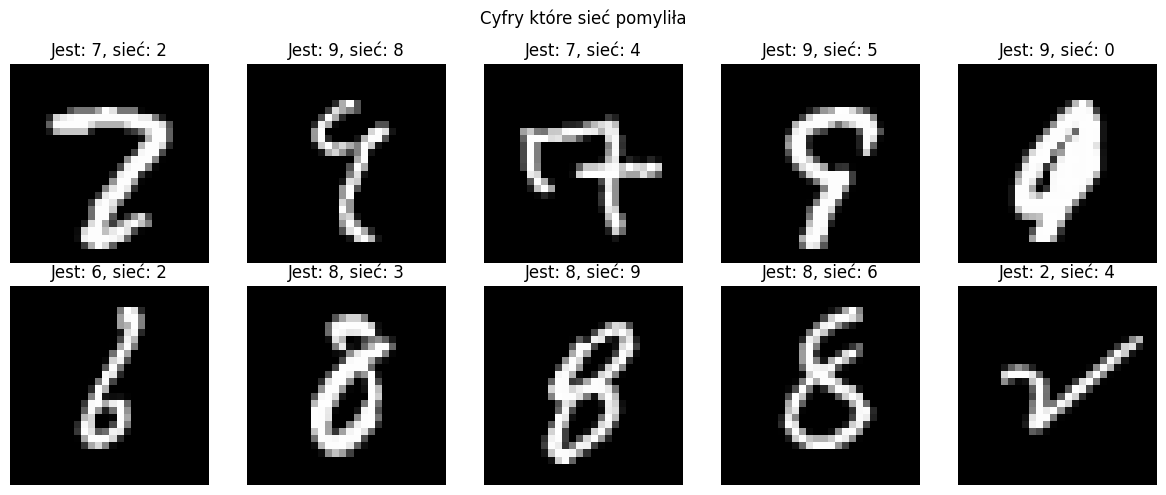

In [6]:
y_pred_labels = np.argmax(y_pred_test, axis=1)
y_true_labels = np.argmax(y_test, axis=1)
mistakes = np.where(y_pred_labels != y_true_labels)[0]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = mistakes[i]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"Jest: {y_true_labels[idx]}, sieć: {y_pred_labels[idx]}")
    ax.axis('off')
plt.suptitle("Cyfry które sieć pomyliła")
plt.tight_layout()
plt.show()